In [1]:
import os
import pandas as pd
import sys

PROJECT_ROOT = os.path.abspath("..")
sys.path.append(PROJECT_ROOT)

from src.inference import CLIPInference
from src.aggregation import aggregate_video_scores
from src.metrics import evaluate
from src.config import FINAL_THRESHOLD, AGGREGATION_METHOD

In [2]:
val_df = pd.read_csv("../data/validation_manifest.csv")

print("Validation segments:", len(val_df))
val_df.head()

Validation segments: 519


,split,class,video_id,segment_uid,segment_path,n_frames,label
0,validation,Abuse,Abuse001_x264,Abuse__Abuse001_x264__seg_0000,/content/data/segments_16/validation/Abuse/Abu...,16,1
1,validation,Abuse,Abuse001_x264,Abuse__Abuse001_x264__seg_0001,/content/data/segments_16/validation/Abuse/Abu...,16,1
2,validation,Abuse,Abuse001_x264,Abuse__Abuse001_x264__seg_0002,/content/data/segments_16/validation/Abuse/Abu...,16,1
3,validation,Abuse,Abuse001_x264,Abuse__Abuse001_x264__seg_0003,/content/data/segments_16/validation/Abuse/Abu...,16,1
4,validation,Abuse,Abuse001_x264,Abuse__Abuse001_x264__seg_0004,/content/data/segments_16/validation/Abuse/Abu...,16,1


In [3]:
from src.config import ANOMALY_CLASSES, NORMAL_CLASSES

# Model init
model = CLIPInference(scoring_mode="max_mean")

# Prompts artık config'ten geliyor
TEXTS = ANOMALY_CLASSES + NORMAL_CLASSES

model.set_text_prompts(TEXTS)

print("Model ready.")
print("Using prompts:")
for t in TEXTS:
    print("-", t)

Model ready.
Using prompts:
- a violent crime happening in a public place
- people physically attacking each other
- a robbery in progress
- an explosion causing chaos
- a dangerous situation involving violence
- criminal activity captured on surveillance camera
- people behaving peacefully in everyday life
- a calm and normal public environment
- ordinary daily activity with no violence
- a safe and uneventful street scene


In [4]:
results = []

for idx, row in val_df.iterrows():
    
    raw_path = row["segment_path"]
    cleaned_path = raw_path.replace("/content/data/", "")
    full_path = os.path.join("..", "data", cleaned_path)

    prediction = model.predict_segment(full_path)

    results.append({
        "video_id": row["video_id"],
        "segment_uid": row["segment_uid"],
        "true_class": row["class"],
        "predicted_label": prediction["predicted_label"],
        "score": prediction["score"]
    })

results_df = pd.DataFrame(results)

print("Processed segments:", len(results_df))

Processed segments: 519


In [5]:
video_df = aggregate_video_scores(
    results_df,
    method="topk",
    k=2
)

video_df.head()

,video_id,score,true_class,is_anomaly
0,Abuse001_x264,0.037109,Abuse,True
1,Abuse002_x264,0.032532,Abuse,True
2,Arrest002_x264,0.049316,Arrest,True
3,Arrest003_x264,0.073975,Arrest,True
4,Arson001_x264,0.050476,Arson,True


In [6]:
metrics = evaluate(video_df, threshold=None)

print("---- Validation Metrics ----")
for k, v in metrics.items():
    if isinstance(v, float):
        print(f"{k}: {v:.4f}")

best_threshold = metrics["best_threshold"]
print("\nSelected threshold:", best_threshold)

---- Validation Metrics ----
accuracy: 0.9286
precision: 0.9615
recall: 0.9615
f1: 0.9615
auc: 0.9231
best_threshold: 0.0163
used_threshold: 0.0163

Selected threshold: 0.01629638671875


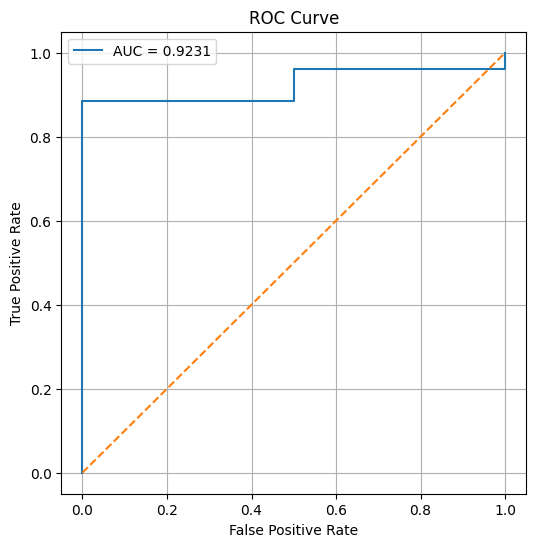

In [7]:
import matplotlib.pyplot as plt

roc_data = metrics["roc_curve"]

plt.figure(figsize=(6,6))
plt.plot(roc_data["fpr"], roc_data["tpr"], label=f"AUC = {metrics['auc']:.4f}")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()

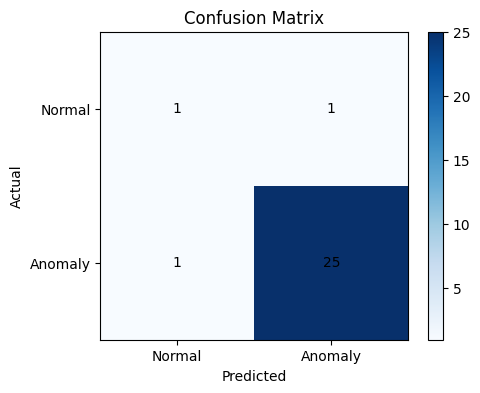

In [8]:
import matplotlib.pyplot as plt
import numpy as np

cm = metrics["confusion_matrix"]

conf_matrix = np.array([
    [cm["tn"], cm["fp"]],
    [cm["fn"], cm["tp"]]
])

plt.figure(figsize=(5,4))
plt.imshow(conf_matrix, cmap="Blues")

plt.xticks([0,1], ["Normal", "Anomaly"])
plt.yticks([0,1], ["Normal", "Anomaly"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, conf_matrix[i, j],
                 ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.colorbar()
plt.show()

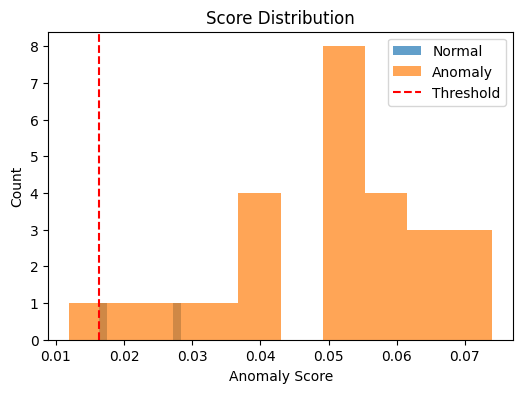

In [9]:
import matplotlib.pyplot as plt

normal_scores = video_df[video_df["is_anomaly"] == False]["score"]
anomaly_scores = video_df[video_df["is_anomaly"] == True]["score"]

plt.figure(figsize=(6,4))

plt.hist(normal_scores, bins=10, alpha=0.7, label="Normal")
plt.hist(anomaly_scores, bins=10, alpha=0.7, label="Anomaly")

plt.axvline(metrics["used_threshold"], color="red", linestyle="--", label="Threshold")

plt.xlabel("Anomaly Score")
plt.ylabel("Count")
plt.title("Score Distribution")
plt.legend()
plt.show()

In [10]:
import os
import json

os.makedirs("../artifacts", exist_ok=True)

with open("../artifacts/threshold.json", "w") as f:
    json.dump({"threshold": float(best_threshold)}, f)

print("Threshold saved to artifacts/threshold.json")

Threshold saved to artifacts/threshold.json
